데이터 크기: (10886, 12)
Fitting 3 folds for each of 128 candidates, totalling 384 fits
Best Parameters: {'alpha': 1, 'colsample_bytree': 0.8, 'lambda': 1, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
RMSE: 39.47
R2 Score: 0.9528


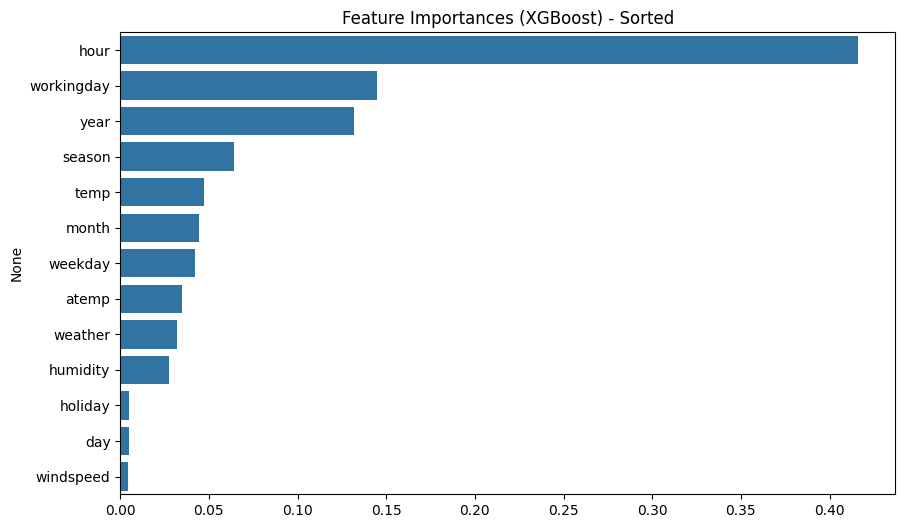

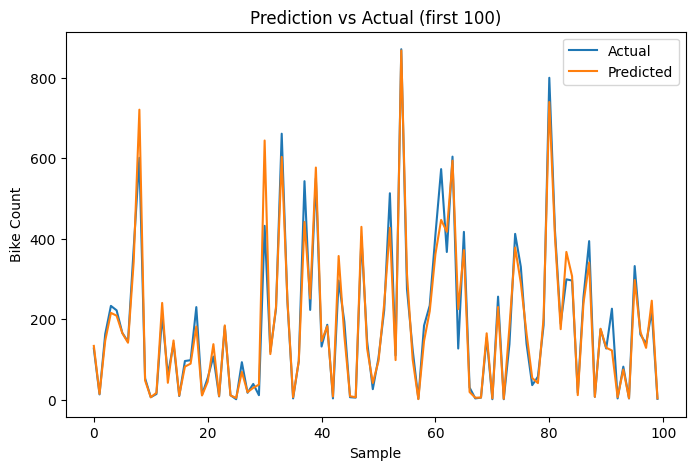

In [2]:
# 사전설치 : pip install xgboost
## 컬럼명,설명  ##
# season,계절 (1: 봄, 2: 여름, 3: 가을, 4: 겨울). 범주형 데이터.
# holiday,공휴일 여부 (0: 공휴일 아님, 1: 공휴일). 이진(binary) 데이터.
# workingday,근무일 여부 (0: 근무일 아님 (주말 또는 공휴일), 1: 근무일). 이진(binary) 데이터.
# weather,날씨 상태 (1: 맑음, 약간 흐림; 2: 안개, 흐림; 3: 약한 눈/비, 천둥번개; 4: 폭우/폭설, 안개). 범주형 데이터.
# temp,정규화된 온도 (섭씨). 0과 1 사이로 스케일링된 값. 실제 온도를 얻으려면 이 값에 스케일링 인자를 곱해야 할 수 있음.
# atemp,정규화된 체감 온도 (섭씨). 0과 1 사이로 스케일링된 값. 체감 온도는 바람, 습도 등을 고려한 온도.
# humidity,정규화된 습도. 0과 1 사이로 스케일링된 값.
# windspeed,정규화된 풍속. 0과 1 사이로 스케일링된 값.
# casual,비등록 사용자(회원이 아닌 사용자)의 자전거 대여 건수. 숫자형 데이터. 주로 예측의 대상이 될 수 있음.
# registered,등록 사용자(회원)의 자전거 대여 건수. 숫자형 데이터. 주로 예측의 대상이 될 수 있음.
# count,총 자전거 대여 건수 (casual + registered). 숫자형 데이터. 이 데이터셋에서 주요 예측 목표 변수(target variable).
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

# 1. 데이터 불러오기
df = pd.read_csv('dataset/bike.csv')
print("데이터 크기:", df.shape)

# 2. 간단한 전처리 및 새로운 피처 추가
df['datetime'] = pd.to_datetime(df['datetime'])
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['hour'] = df['datetime'].dt.hour
df['weekday'] = df['datetime'].dt.weekday

# 필요 없는 컬럼 제거
df = df.drop(['datetime', 'casual', 'registered'], axis=1)

# 로그 변환 (count가 편향되어 있으므로, 예로 특정시간대에는 많고, 새벽등 다른 시간대에는 적은 경우, 정규분포로 변환하여 모델학습 안정화)
df['count'] = np.log1p(df['count'])

# 3. X, y 분리
X = df.drop('count', axis=1)
y = df['count']

# 4. 학습/검증 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. 표준화 (XGBoost에는 꼭 필요는 없지만 예시로 포함)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. 하이퍼파라미터 튜닝: GridSearchCV
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)   # 제곱오차(reg:squarederror)로 MSE를 뜻함

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1],   # 각 트리 학습에 사용되는 데이터 샘플 비율, 과적합 방지
    'colsample_bytree': [0.8, 1],   # 각 트리에서 사용되는 피처(변수)의 비율, 과적합 방지
    'alpha': [0, 1],   # L1 정규화 (0: L1정규화 적용안함, 0.1~1: 약한 정규화, 1~10: 중간정규화, 10~100: 강한 정규화, 100이상: 매우강한 정규화)
    'lambda': [1, 10]  # L2 정규화 (0: L2정규화 적용안함, 0.1~1: 약한 정규화, 1~10: 중간정규화, 10~100: 강한 정규화, 100이상: 매우강한 정규화)
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error', # GridSearchCV는 점수가 높을수록 좋은 모델로 간주함으로 RMSE에 negative(-)가 붙어서 덜 음수인 값이 더 나은 모델로 평가되도록 함
    cv=3,
    verbose=1,
    n_jobs=-1  # (n_jobs=1: 병렬처리 없이 단일 CPU코어로 순차적 학습, n_jobs=n: n개의 CPU코어로 사용, n_jobs=-1: 모든 CPU코어 사용)
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)

# 7. 최적 모델로 예측
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)

# 역변환 (log1p → 원래 값)
y_test_exp = np.expm1(y_test)
y_pred_exp = np.expm1(y_pred)

# 8. 평가
rmse = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp))
r2 = r2_score(y_test_exp, y_pred_exp)

print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")

# 9. 피처 중요도 시각화
importances = best_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]  # argsort: 오름차순으로 정렬했을 때의 인덱스를 반환, [::-1}: 중요도 내림차순 정렬
sorted_features = X.columns[sorted_idx]
sorted_importances = importances[sorted_idx]

plt.figure(figsize=(10, 6))
sns.barplot(
    x=sorted_importances,
    y=sorted_features
)
plt.title("Feature Importances (XGBoost) - Sorted")
plt.show()

# 10. 예측 vs 실제 시각화
plt.figure(figsize=(8, 5))
plt.plot(y_test_exp.values[:100], label="Actual")  # 테스트 데이터의 첫 100개 샘플만 시각화
plt.plot(y_pred_exp[:100], label="Predicted") # 예측 데이터의 첫 100개 샘플만 시각화
plt.legend()
plt.title("Prediction vs Actual (first 100)")
plt.xlabel("Sample")
plt.ylabel("Bike Count")
plt.show()
